<a href="https://colab.research.google.com/github/AndreiAf02/Data-Balancing-in-ML-DNN/blob/main/CIFAR10_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##CIFAR-10 Dataset - ML Classification with Random Under/Oversampling

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from time import perf_counter



from sklearn.preprocessing import StandardScaler, MinMaxScaler
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
# !pip install pytorch-tabnet

# from pytorch_tabnet.tab_model import TabNetClassifier
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sklearn.datasets import make_classification
import random

from imblearn.datasets import make_imbalance



from keras.datasets import mnist, fashion_mnist, cifar10
# import tensorflow_datasets as tfds




## Downloading the MNIST Data:

In [2]:
(train_images, train_labels), (test_images, test_labels) = cifar10.load_data()

# (train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [3]:
np.unique(train_labels)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

[4]


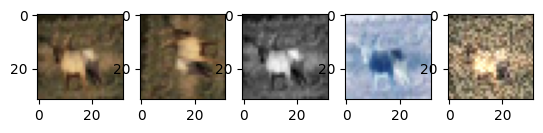

In [4]:
i = 3

print(train_labels[i])

figure_for_plotting = train_images[i] #.transpose((1, 0, 2))
plt.subplot(1, 5, 1)
plt.imshow(figure_for_plotting)

plt.subplot(1, 5, 2)
plt.imshow(figure_for_plotting.transpose((1, 0, 2)))

# np.clip(noisy_figure, 0, 255)
gs_figure_for_plotting = np.mean(train_images[i],axis=2)
plt.subplot(1, 5, 3)
plt.imshow(gs_figure_for_plotting, cmap='gray')


plt.subplot(1, 5, 4)
plt.imshow(-figure_for_plotting)


noisy_figure = figure_for_plotting + np.random.randint(0,100,size=(figure_for_plotting.shape[0], figure_for_plotting.shape[1], 1))
noisy_figure = np.clip(noisy_figure, 0, 255)

plt.subplot(1, 5, 5)
plt.imshow(noisy_figure)

## Creating the Imbalanced training set using Data Augmentation:

15000


Text(0.5, 1.0, 'Noisy')

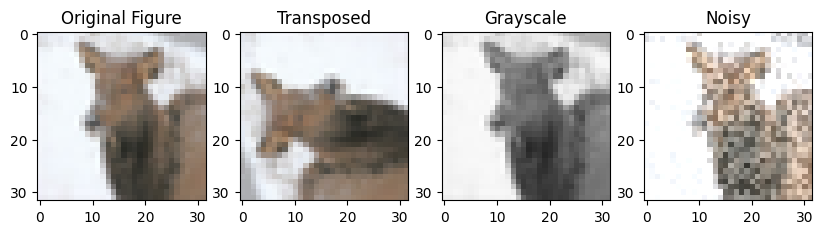

In [5]:
maj_label=4
min_label=7

max_noise = 100

# train_binary_maj = train_images[np.where(np.isin(train_labels,[maj_label,min_label]))]
maj_index = np.where(train_labels == maj_label)
train_binary_label1 = train_images[maj_index[0]]

# train_binary_maj = train_binary_label1

orig_maj_len = len(train_binary_label1)

# train_binary_maj.shape

# Incorporating the transposed image:
maj_transpose = train_binary_label1.transpose((0, 2, 1, 3))
# train_binary_maj = np.append(train_binary_maj, maj_transpose, axis=0)
train_binary_maj = maj_transpose

# ## Incorporating the negative image:
# maj_negative = 255 - train_binary_label1
# train_binary_maj = np.append(train_binary_maj, maj_negative, axis=0)

## Incoporating the grayscale image:
gs_fig = train_binary_label1.mean(axis=3).astype(int)
gs_fig = np.concatenate(([gs_fig], [gs_fig], [gs_fig]), axis=0)
gs_fig = gs_fig.transpose((1, 2, 3, 0))
gs_fig.shape
train_binary_maj = np.append(train_binary_maj, gs_fig, axis=0)

## Incorporating the noisy image:
noisy_figure = train_binary_label1 + np.random.randint(0,max_noise,size=(train_binary_label1.shape[0], train_binary_label1.shape[1], train_binary_label1.shape[2], 1))
noisy_figure = np.clip(noisy_figure, 0, 255)
train_binary_maj = np.append(train_binary_maj, noisy_figure, axis=0)


print(len(train_binary_maj))


## Plotting the example figures:
plt.figure(figsize=(10, 30))
plt.subplot(1, 4, 1)
plt.imshow(train_binary_label1[orig_maj_len-1])
plt.title('Original Figure')

plt.subplot(1, 4, 2)
plt.imshow(train_binary_maj[orig_maj_len-1])
plt.title('Transposed')

# plt.subplot(1, 5, 3)
# plt.imshow(train_binary_maj[3*orig_maj_len-1])
# plt.title('Negative')

plt.subplot(1, 4, 3)
plt.imshow(train_binary_maj[2*orig_maj_len-1])
plt.title('Grayscale')

plt.subplot(1, 4, 4)
plt.imshow(train_binary_maj[3*orig_maj_len-1])
plt.title('Noisy')




Text(0.5, 1.0, 'Original Figure')

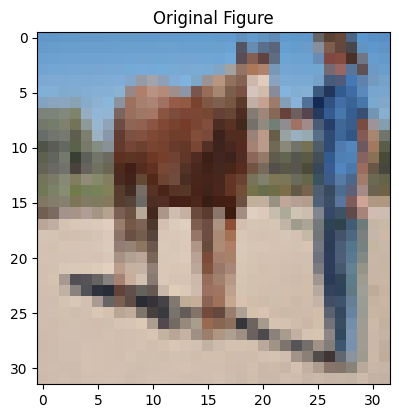

In [6]:
min_index = np.where(train_labels == min_label)
train_binary_label2 = train_images[min_index[0]]


train_binary_min = train_binary_label2

# noisy_figure = train_binary_label2 + np.random.randint(0,max_noise,size=(train_binary_label2.shape[0], train_binary_label2.shape[1], train_binary_label2.shape[2], 1))
# noisy_figure = np.clip(noisy_figure, 0, 255)
# train_binary_min = noisy_figure


plt.figure(figsize=(10, 12))
plt.subplot(1, 2, 1)
plt.imshow(train_binary_label2[-1])
plt.title('Original Figure')

# plt.subplot(1, 2, 2)
# plt.imshow(train_binary_min[-1])
# plt.title('Noisy Figure')

In [7]:
print(train_binary_maj.shape)
print(train_binary_min.shape)


train_maj_label = [maj_label]*len(train_binary_maj)
train_min_label = [min_label]*len(train_binary_min)

train_maj_label_binary = [0]*len(train_binary_maj)
train_min_label_binary = [1]*len(train_binary_min)

train_binary_total = np.append(train_binary_maj, train_binary_min, axis=0)
train_label_total = train_maj_label + train_min_label
train_label_total_binary = train_maj_label_binary + train_min_label_binary

pd.Series(train_label_total_binary).value_counts()


(15000, 32, 32, 3)
(5000, 32, 32, 3)


,count
0,15000
1,5000


In [8]:
train_binary_scaled = train_binary_total.astype('float32')/255.
train_binary_flattened = train_binary_scaled.reshape(train_binary_scaled.shape[0], -1)
train_binary_flattened = pd.DataFrame(train_binary_flattened)
train_binary_flattened['Y'] = train_label_total_binary

train_binary_flattened.tail()

,0,1,2,3,4,5,6,7,8,9,...,3063,3064,3065,3066,3067,3068,3069,3070,3071,Y
19995,0.698039,0.741176,0.745098,0.501961,0.552941,0.560784,0.533333,0.592157,0.576471,0.498039,...,0.403922,0.509804,0.247059,0.403922,0.517647,0.235294,0.368627,0.494118,0.215686,1
19996,0.227451,0.274510,0.235294,0.250980,0.301961,0.262745,0.203922,0.250980,0.211765,0.243137,...,0.627451,0.615686,0.074510,0.631373,0.623529,0.070588,0.545098,0.517647,0.078431,1
19997,0.870588,0.862745,0.870588,0.854902,0.847059,0.854902,0.886275,0.878431,0.886275,0.909804,...,0.164706,0.145098,0.129412,0.439216,0.454902,0.470588,0.560784,0.592157,0.650980,1
19998,0.643137,0.639216,0.588235,0.368627,0.321569,0.219608,0.466667,0.400000,0.301961,0.494118,...,0.898039,0.941176,0.917647,0.874510,0.898039,0.882353,0.996078,0.996078,0.996078,1
19999,0.380392,0.592157,0.788235,0.384314,0.596078,0.788235,0.388235,0.600000,0.788235,0.388235,...,0.803922,0.729412,0.666667,0.768627,0.701961,0.639216,0.764706,0.698039,0.639216,1


## Creating the Imbalanced testing set using Data Augmentation:

3000


Text(0.5, 1.0, 'Noisy')

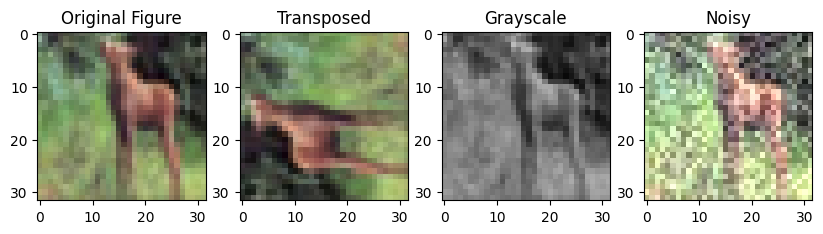

In [9]:
maj_index = np.where(test_labels == maj_label)
test_binary_label1 = test_images[maj_index[0]]

# test_binary_maj = test_binary_label1

orig_maj_len = len(test_binary_label1)

# test_binary_maj.shape

# Incorporating the transposed image:
maj_transpose = test_binary_label1.transpose((0, 2, 1, 3))
# test_binary_maj = np.append(test_binary_maj, maj_transpose, axis=0)
test_binary_maj = maj_transpose

# ## Incorporating the negative image:
# maj_negative = 255 - test_binary_label1
# test_binary_maj = np.append(test_binary_maj, maj_negative, axis=0)

## Incoporating the grayscale image:
gs_fig = test_binary_label1.mean(axis=3).astype(int)
gs_fig = np.concatenate(([gs_fig], [gs_fig], [gs_fig]), axis=0)
gs_fig = gs_fig.transpose((1, 2, 3, 0))
gs_fig.shape
test_binary_maj = np.append(test_binary_maj, gs_fig, axis=0)

## Incorporating the noisy image:
noisy_figure = test_binary_label1 + np.random.randint(0,max_noise,size=(test_binary_label1.shape[0], test_binary_label1.shape[1], test_binary_label1.shape[2], 1))
noisy_figure = np.clip(noisy_figure, 0, 255)
test_binary_maj = np.append(test_binary_maj, noisy_figure, axis=0)


print(len(test_binary_maj))


## Plotting the example figures:
plt.figure(figsize=(10, 30))
plt.subplot(1, 4, 1)
plt.imshow(test_binary_label1[orig_maj_len-1])
plt.title('Original Figure')

plt.subplot(1, 4, 2)
plt.imshow(test_binary_maj[orig_maj_len-1])
plt.title('Transposed')

# plt.subplot(1, 5, 3)
# plt.imshow(test_binary_maj[3*orig_maj_len-1])
# plt.title('Negative')

plt.subplot(1, 4, 3)
plt.imshow(test_binary_maj[2*orig_maj_len-1])
plt.title('Grayscale')

plt.subplot(1, 4, 4)
plt.imshow(test_binary_maj[3*orig_maj_len-1])
plt.title('Noisy')




Text(0.5, 1.0, 'Original Figure')

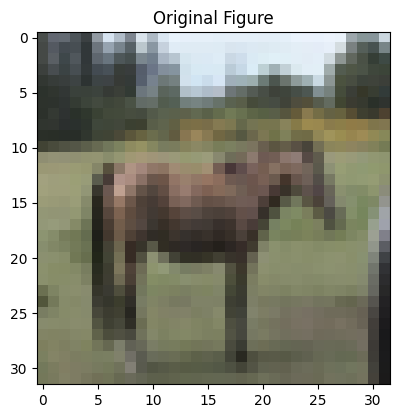

In [10]:
min_index = np.where(test_labels == min_label)
test_binary_label2 = test_images[min_index[0]]

test_binary_min = test_binary_label2

# noisy_figure = test_binary_label2 + np.random.randint(0,max_noise,size=(test_binary_label2.shape[0], test_binary_label2.shape[1], test_binary_label2.shape[2], 1))
# noisy_figure = np.clip(noisy_figure, 0, 255)
# test_binary_min = noisy_figure


plt.figure(figsize=(10, 12))
plt.subplot(1, 2, 1)
plt.imshow(test_binary_label2[-1])
plt.title('Original Figure')

# plt.subplot(1, 2, 2)
# plt.imshow(test_binary_min[-1])
# plt.title('Noisy Figure')

In [11]:
print(test_binary_maj.shape)
print(test_binary_min.shape)


test_maj_label = [maj_label]*len(test_binary_maj)
test_min_label = [min_label]*len(test_binary_min)

test_maj_label_binary = [0]*len(test_binary_maj)
test_min_label_binary = [1]*len(test_binary_min)

test_binary_total = np.append(test_binary_maj, test_binary_min, axis=0)
test_label_total = test_maj_label + test_min_label
test_label_total_binary = test_maj_label_binary + test_min_label_binary

pd.Series(test_label_total_binary).value_counts()


(3000, 32, 32, 3)
(1000, 32, 32, 3)


,count
0,3000
1,1000


In [12]:
test_binary_scaled = test_binary_total.astype('float32')/255.
test_binary_flattened = test_binary_scaled.reshape(test_binary_scaled.shape[0], -1)
test_binary_flattened = pd.DataFrame(test_binary_flattened)
test_binary_flattened['Y'] = test_label_total_binary

test_binary_flattened.tail()

,0,1,2,3,4,5,6,7,8,9,...,3063,3064,3065,3066,3067,3068,3069,3070,3071,Y
3995,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.776471,0.721569,0.596078,0.772549,0.709804,0.576471,0.780392,0.709804,0.572549,1
3996,0.062745,0.094118,0.050980,0.019608,0.058824,0.023529,0.031373,0.086275,0.043137,0.043137,...,0.505882,0.415686,0.329412,0.498039,0.407843,0.321569,0.482353,0.400000,0.309804,1
3997,0.125490,0.129412,0.086275,0.172549,0.219608,0.117647,0.243137,0.274510,0.172549,0.380392,...,0.701961,0.580392,0.494118,0.705882,0.580392,0.494118,0.698039,0.556863,0.478431,1
3998,0.329412,0.470588,0.384314,0.384314,0.490196,0.403922,0.388235,0.490196,0.411765,0.392157,...,0.552941,0.580392,0.552941,0.498039,0.517647,0.498039,0.333333,0.352941,0.317647,1
3999,0.286275,0.305882,0.294118,0.384314,0.403922,0.443137,0.388235,0.415686,0.447059,0.301961,...,0.454902,0.450980,0.368627,0.266667,0.254902,0.227451,0.105882,0.101961,0.101961,1


In [13]:
train_binary_flattened['test'] = 0
test_binary_flattened['test'] = 1
data2 = pd.concat([train_binary_flattened, test_binary_flattened])

data2.tail()

,0,1,2,3,4,5,6,7,8,9,...,3064,3065,3066,3067,3068,3069,3070,3071,Y,test
3995,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.721569,0.596078,0.772549,0.709804,0.576471,0.780392,0.709804,0.572549,1,1
3996,0.062745,0.094118,0.050980,0.019608,0.058824,0.023529,0.031373,0.086275,0.043137,0.043137,...,0.415686,0.329412,0.498039,0.407843,0.321569,0.482353,0.400000,0.309804,1,1
3997,0.125490,0.129412,0.086275,0.172549,0.219608,0.117647,0.243137,0.274510,0.172549,0.380392,...,0.580392,0.494118,0.705882,0.580392,0.494118,0.698039,0.556863,0.478431,1,1
3998,0.329412,0.470588,0.384314,0.384314,0.490196,0.403922,0.388235,0.490196,0.411765,0.392157,...,0.580392,0.552941,0.498039,0.517647,0.498039,0.333333,0.352941,0.317647,1,1
3999,0.286275,0.305882,0.294118,0.384314,0.403922,0.443137,0.388235,0.415686,0.447059,0.301961,...,0.450980,0.368627,0.266667,0.254902,0.227451,0.105882,0.101961,0.101961,1,1


In [14]:
data2['Y'].value_counts()

,count
Y,
0,18000
1,6000


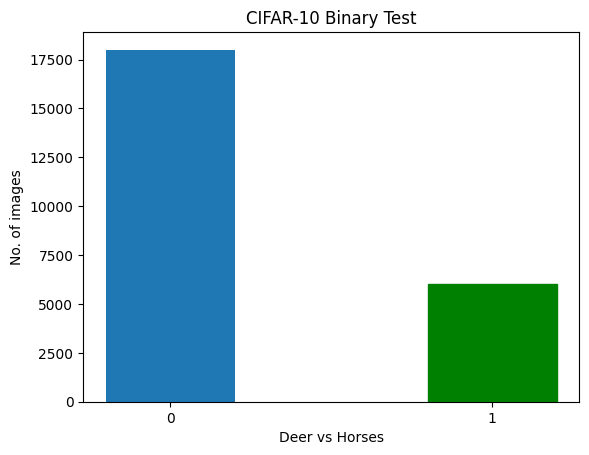

In [15]:
barlist = plt.bar([str(0),str(1)], data2['Y'].value_counts(), width = 0.4)
barlist[1].set_color('g')

plt.xlabel("Deer vs Horses")
plt.ylabel("No. of images")
plt.title("CIFAR-10 Binary Test")
plt.show()

# Full Dataset:

## DNN Classification Algorithm:

In [16]:
def create_dnn_model(input_shape):
  model = models.Sequential([layers.Dense(64, activation='relu', input_dim=input_shape),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid')  # For binary classification (yes/no)
    ])

  model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC'])

  return model



def train_and_evaluate_ml(model, X_train, X_test, y_train, y_test, domain):

    # time_start = perf_counter()

    # Training and validation
    model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

    # Predict probabilities and calculate AUC
    y_pred_prob = model.predict(X_test).ravel()
    auc = roc_auc_score(y_test, y_pred_prob)
    print(f"AUC-ROC: {auc}")

    # Compute ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

    # Convert probabilities to binary predictions for confusion matrix
    y_pred_class = (y_pred_prob >= 0.5).astype(int)

    # Compute and print classification report
    class_report = classification_report(y_test, y_pred_class)
    print("Classification Report:")
    print(class_report)

    # Compute confusion matrix
    conf_matrix = confusion_matrix(y_test, y_pred_class)

    fpr = conf_matrix[0][1]/(conf_matrix[0][0]+conf_matrix[0][1])
    tnr = 1-fpr

    fnr = conf_matrix[1][0]/(conf_matrix[1][0] + conf_matrix[1][1])
    tpr = 1 - fnr
    print('FPR', fpr, 'TPR:', tpr, 'FNR:', fnr, 'TNR:', tnr)

    # conf_disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)

    # ## To deactivate after!!! ----------------------------------------
    # ##### Plot ROC curve and Confusion Matrix side by side
    # fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # # ROC Curve
    # ax1.plot(fpr, tpr, color='blue', label=f'AUC-ROC = {auc:.2f}')
    # ax1.plot([0, 1], [0, 1], color='gray', linestyle='--')
    # ax1.set_xlabel('False Positive Rate')
    # ax1.set_ylabel('True Positive Rate')
    # ax1.set_title('Receiver Operating Characteristic (ROC) Curve')
    # ax1.legend(loc='lower right')
    # ax1.grid()

    # # Confusion Matrix
    # conf_disp.plot(ax=ax2, cmap='Blues')
    # ax2.set_title('Confusion Matrix')
    # plt.tight_layout()
    # plt.show()
    ## To deactivate after!!! ----------------------------------------

    # Calculate precision and recall for different thresholds
    precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob)

    # Find the threshold where precision and recall are balanced
    f1_scores = 2 * (precision * recall) / (precision + recall)
    best_threshold = thresholds[f1_scores.argmax()]

    print(f"Best threshold based on F1-score: {best_threshold}")

    return fpr, tnr, fnr, tpr


In [17]:
train_data = data2[data2['test']==0]
train_data = train_data.iloc[:, :-1]
X_train = train_data.iloc[:, :-1]
y_train = train_data.iloc[:, -1]

test_data = data2[data2['test']==1]
test_data = test_data.iloc[:, :-1]
X_test = test_data.iloc[:, :-1]
y_test = test_data.iloc[:, -1]

In [18]:
y_train.value_counts()

,count
Y,
0,15000
1,5000


In [19]:
y_test.value_counts()

,count
Y,
0,3000
1,1000


In [20]:
print('X_train:',np.shape(X_train))
print('y_train:',np.shape(y_train))
print('X_test:',np.shape(X_test))
print('y_test:',np.shape(y_test))

X_train: (20000, 3072)
y_train: (20000,)
X_test: (4000, 3072)
y_test: (4000,)


In [21]:
## Establishing the Under/Oversampling values and imbalance ratio:

undersample_size = min(train_data.iloc[:,-1].value_counts())
oversample_size = max(train_data.iloc[:,-1].value_counts())


data_majority = train_data[train_data.iloc[:,-1]==0]
data_minority = train_data[train_data.iloc[:,-1]==1]

print(undersample_size)
print(oversample_size)

5000
15000


## Imbalanced (Original) data:

In [ ]:
times = 50

FPR = []
TPR = []
FNR = []
TNR = []


for i in range(times):
    model_source = create_dnn_model(X_train.shape[1])
    result_imbalanced = train_and_evaluate_ml(model_source, X_train, X_test, y_train, y_test, "Source")
    # result_TL_imbalanced = Transductive_TL(model_source, X_T_full, y_T_full, "Target")

    FPR.append(result_imbalanced[0])
    TNR.append(result_imbalanced[1])
    FNR.append(result_imbalanced[2])
    TPR.append(result_imbalanced[3])

ParamFit = pd.DataFrame([FPR, TPR, FNR, TNR]).T
ParamFit.columns=['FPR', 'TPR', 'FNR', 'TNR']
# print(ParamFit)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - AUC: 0.6495 - loss: 0.2376 - val_AUC: 0.0000e+00 - val_loss: 4.0458
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - AUC: 0.7508 - loss: 0.1919 - val_AUC: 0.0000e+00 - val_loss: 2.6113
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - AUC: 0.8068 - loss: 0.1760 - val_AUC: 0.0000e+00 - val_loss: 1.4710
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - AUC: 0.8372 - loss: 0.1728 - val_AUC: 0.0000e+00 - val_loss: 2.2097
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - AUC: 0.8567 - loss: 0.1586 - val_AUC: 0.0000e+00 - val_loss: 1.4329
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - AUC: 0.8833 - loss: 0.1556 - val_AUC: 0.0000e+00 - val_loss: 2.8678
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - AUC: 0.8742 - loss: 0.1493 - val_AUC: 0.0000e+00 - val_loss: 1.5558
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - AUC: 0.8951 - loss: 0.1450 - val_AUC: 0.0000e+00 - val_loss: 1.6198
Epoch 9/10
500/500 ━━━━━

In [ ]:
print(ParamFit)
ParamFit.to_csv('CIFAR_ML_Imbalanced.csv')

        FPR    TPR    FNR       TNR
0  0.005333  0.303  0.697  0.994667


In [ ]:
print('Mean FNR:', ParamFit['FNR'].mean())
print('StDev FNR:', ParamFit['FNR'].std())

Mean FNR: 0.697
StDev FNR: nan


# Random Undersampling (RUS) to balance Dataset:

## SRS Sample without Replacement:

In [ ]:
times = 100

FPR = []
TPR = []
FNR = []
TNR = []


for i in range(times):
    data_maj_rus = data_majority.sample(n=undersample_size, replace=False)
    data_SRS_RUS = pd.concat([data_maj_rus, data_minority])
    X_SRS_train = data_SRS_RUS.iloc[:, :-1]
    y_SRS_train = data_SRS_RUS.iloc[:, -1]
    model_SRS = create_dnn_model(X_SRS_train.shape[1])
    result_SRS = train_and_evaluate_ml(model_SRS, X_SRS_train, X_test, y_SRS_train, y_test, "Source")

    FPR.append(result_SRS[0])
    TNR.append(result_SRS[1])
    FNR.append(result_SRS[2])
    TPR.append(result_SRS[3])

ParamFit = pd.DataFrame([FPR, TPR, FNR, TNR]).T
ParamFit.columns=['FPR', 'TPR', 'FNR', 'TNR']
# print(ParamFit)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - AUC: 0.6398 - loss: 0.6524 - val_AUC: 0.0000e+00 - val_loss: 1.1998
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.8552 - loss: 0.4546 - val_AUC: 0.0000e+00 - val_loss: 0.7910
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.8730 - loss: 0.4246 - val_AUC: 0.0000e+00 - val_loss: 0.7714
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - AUC: 0.8871 - loss: 0.3990 - val_AUC: 0.0000e+00 - val_loss: 0.5519
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - AUC: 0.8979 - loss: 0.3793 - val_AUC: 0.0000e+00 - val_loss: 1.0300
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.9079 - loss: 0.3620 - val_AUC: 0.0000e+00 - val_loss: 0.5000
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.9032 - loss: 0.3649 - val_AUC: 0.0000e+00 - val_loss: 0.8623
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.9036 - loss: 0.3713 - val_AUC: 0.0000e+00 - val_loss: 0.4566
Epoch 9/10
250/250 ━━━━━

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - AUC: 0.6592 - loss: 0.6153 - val_AUC: 0.0000e+00 - val_loss: 0.8266
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - AUC: 0.8327 - loss: 0.4767 - val_AUC: 0.0000e+00 - val_loss: 0.3847
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.8707 - loss: 0.4240 - val_AUC: 0.0000e+00 - val_loss: 0.6439
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.8878 - loss: 0.3964 - val_AUC: 0.0000e+00 - val_loss: 0.6716
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.8889 - loss: 0.3989 - val_AUC: 0.0000e+00 - val_loss: 0.3737
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.9055 - loss: 0.3665 - val_AUC: 0.0000e+00 - val_loss: 0.6332
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - AUC: 0.8954 - loss: 0.3818 - val_AUC: 0.0000e+00 - val_loss: 0.6667
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - AUC: 0.9087 - loss: 0.3572 - val_AUC: 0.0000e+00 - val_loss: 0.9929
Epoch 9/10
250/250 ━━━━

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - AUC: 0.6571 - loss: 0.6237 - val_AUC: 0.0000e+00 - val_loss: 0.9627
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - AUC: 0.8449 - loss: 0.4634 - val_AUC: 0.0000e+00 - val_loss: 0.3392
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - AUC: 0.8749 - loss: 0.4239 - val_AUC: 0.0000e+00 - val_loss: 0.7756
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - AUC: 0.8911 - loss: 0.3896 - val_AUC: 0.0000e+00 - val_loss: 0.9125
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - AUC: 0.8951 - loss: 0.3880 - val_AUC: 0.0000e+00 - val_loss: 0.6668
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - AUC: 0.9057 - loss: 0.3651 - val_AUC: 0.0000e+00 - val_loss: 0.6653
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - AUC: 0.8947 - loss: 0.3858 - val_AUC: 0.0000e+00 - val_loss: 0.5686
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - AUC: 0.9053 - loss: 0.3633 - val_AUC: 0.0000e+00 - val_loss: 0.3293
Epoch 9/10
250/250 ━━━━

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - AUC: 0.7085 - loss: 0.6020 - val_AUC: 0.0000e+00 - val_loss: 0.5368
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - AUC: 0.8740 - loss: 0.4232 - val_AUC: 0.0000e+00 - val_loss: 0.7519
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - AUC: 0.8711 - loss: 0.4233 - val_AUC: 0.0000e+00 - val_loss: 0.6628
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - AUC: 0.8815 - loss: 0.4054 - val_AUC: 0.0000e+00 - val_loss: 0.4403
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - AUC: 0.8876 - loss: 0.3954 - val_AUC: 0.0000e+00 - val_loss: 0.4711
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - AUC: 0.9056 - loss: 0.3644 - val_AUC: 0.0000e+00 - val_loss: 0.4423
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - AUC: 0.8903 - loss: 0.3937 - val_AUC: 0.0000e+00 - val_loss: 0.6135
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - AUC: 0.9141 - loss: 0.3478 - val_AUC: 0.0000e+00 - val_loss: 0.5902
Epoch 9/10
250/250 ━━━━

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - AUC: 0.6848 - loss: 0.6041 - val_AUC: 0.0000e+00 - val_loss: 0.4670
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - AUC: 0.8406 - loss: 0.4655 - val_AUC: 0.0000e+00 - val_loss: 0.5928
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - AUC: 0.8723 - loss: 0.4198 - val_AUC: 0.0000e+00 - val_loss: 1.1150
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - AUC: 0.8792 - loss: 0.4126 - val_AUC: 0.0000e+00 - val_loss: 0.8900
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - AUC: 0.8905 - loss: 0.3922 - val_AUC: 0.0000e+00 - val_loss: 0.6740
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - AUC: 0.8937 - loss: 0.3856 - val_AUC: 0.0000e+00 - val_loss: 0.8922
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - AUC: 0.9033 - loss: 0.3679 - val_AUC: 0.0000e+00 - val_loss: 0.5819
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - AUC: 0.9034 - loss: 0.3672 - val_AUC: 0.0000e+00 - val_loss: 0.5330
Epoch 9/10
250/250 ━━━━

In [ ]:
print(ParamFit)
ParamFit.to_csv('CIFAR_ML_SRS_RUS.csv')

         FPR    TPR    FNR       TNR
0   0.198667  0.851  0.149  0.801333
1   0.053000  0.621  0.379  0.947000
2   0.192000  0.847  0.153  0.808000
3   0.073667  0.722  0.278  0.926333
4   0.120667  0.795  0.205  0.879333
..       ...    ...    ...       ...
95  0.157333  0.821  0.179  0.842667
96  0.059667  0.675  0.325  0.940333
97  0.066667  0.705  0.295  0.933333
98  0.067333  0.700  0.300  0.932667
99  0.049000  0.648  0.352  0.951000

[100 rows x 4 columns]


In [ ]:
print('Mean FNR:', ParamFit['FNR'].mean())
print('StDev FNR:', ParamFit['FNR'].std())

Mean FNR: 0.27042
StDev FNR: 0.08615187200812904


## Simple Random Sampling with Replacement:

In [ ]:
times = 100

FPR = []
TPR = []
FNR = []
TNR = []


for i in range(times):
    data_maj_rus = data_majority.sample(n=undersample_size, replace=True)
    data_SRSwR_RUS = pd.concat([data_maj_rus, data_minority])
    X_SRSwR_train = data_SRSwR_RUS.iloc[:, :-1]
    y_SRSwR_train = data_SRSwR_RUS.iloc[:, -1]
    model_SRSwR = create_dnn_model(X_SRSwR_train.shape[1])
    result_SRSwR = train_and_evaluate_ml(model_SRSwR, X_SRSwR_train, X_test, y_SRSwR_train, y_test, "Source")

    FPR.append(result_SRSwR[0])
    TNR.append(result_SRSwR[1])
    FNR.append(result_SRSwR[2])
    TPR.append(result_SRSwR[3])

ParamFit = pd.DataFrame([FPR, TPR, FNR, TNR]).T
ParamFit.columns=['FPR', 'TPR', 'FNR', 'TNR']

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - AUC: 0.6562 - loss: 0.6443 - val_AUC: 0.0000e+00 - val_loss: 0.8592
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - AUC: 0.8515 - loss: 0.4518 - val_AUC: 0.0000e+00 - val_loss: 0.8233
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - AUC: 0.8535 - loss: 0.4486 - val_AUC: 0.0000e+00 - val_loss: 0.9825
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - AUC: 0.8768 - loss: 0.4098 - val_AUC: 0.0000e+00 - val_loss: 0.9739
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - AUC: 0.8815 - loss: 0.4099 - val_AUC: 0.0000e+00 - val_loss: 0.4915
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - AUC: 0.9052 - loss: 0.3667 - val_AUC: 0.0000e+00 - val_loss: 0.4121
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - AUC: 0.8799 - loss: 0.4065 - val_AUC: 0.0000e+00 - val_loss: 0.7405
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - AUC: 0.9087 - loss: 0.3570 - val_AUC: 0.0000e+00 - val_loss: 0.6136
Epoch 9/10
250/250 ━━━━

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - AUC: 0.6462 - loss: 0.6508 - val_AUC: 0.0000e+00 - val_loss: 0.6921
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - AUC: 0.8230 - loss: 0.4848 - val_AUC: 0.0000e+00 - val_loss: 0.8157
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - AUC: 0.8707 - loss: 0.4295 - val_AUC: 0.0000e+00 - val_loss: 0.4453
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - AUC: 0.8836 - loss: 0.4028 - val_AUC: 0.0000e+00 - val_loss: 0.7435
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - AUC: 0.8929 - loss: 0.3875 - val_AUC: 0.0000e+00 - val_loss: 0.6564
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - AUC: 0.9021 - loss: 0.3685 - val_AUC: 0.0000e+00 - val_loss: 0.7643
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - AUC: 0.9098 - loss: 0.3554 - val_AUC: 0.0000e+00 - val_loss: 0.5568
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - AUC: 0.9173 - loss: 0.3375 - val_AUC: 0.0000e+00 - val_loss: 0.8711
Epoch 9/10
250/250 ━━━━

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - AUC: 0.6298 - loss: 0.6367 - val_AUC: 0.0000e+00 - val_loss: 0.8825
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - AUC: 0.8279 - loss: 0.4844 - val_AUC: 0.0000e+00 - val_loss: 0.5228
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - AUC: 0.8731 - loss: 0.4214 - val_AUC: 0.0000e+00 - val_loss: 0.4377
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - AUC: 0.8757 - loss: 0.4142 - val_AUC: 0.0000e+00 - val_loss: 0.7166
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - AUC: 0.8896 - loss: 0.3926 - val_AUC: 0.0000e+00 - val_loss: 0.7680
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - AUC: 0.9007 - loss: 0.3716 - val_AUC: 0.0000e+00 - val_loss: 0.5628
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - AUC: 0.9021 - loss: 0.3658 - val_AUC: 0.0000e+00 - val_loss: 0.6216
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - AUC: 0.9123 - loss: 0.3476 - val_AUC: 0.0000e+00 - val_loss: 0.4483
Epoch 9/10
250/250 ━━━━

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - AUC: 0.6729 - loss: 0.6175 - val_AUC: 0.0000e+00 - val_loss: 0.6845
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - AUC: 0.8421 - loss: 0.4633 - val_AUC: 0.0000e+00 - val_loss: 0.6583
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - AUC: 0.8757 - loss: 0.4156 - val_AUC: 0.0000e+00 - val_loss: 0.4054
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - AUC: 0.8780 - loss: 0.4108 - val_AUC: 0.0000e+00 - val_loss: 0.4217
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - AUC: 0.8929 - loss: 0.3907 - val_AUC: 0.0000e+00 - val_loss: 0.7008
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - AUC: 0.8928 - loss: 0.3857 - val_AUC: 0.0000e+00 - val_loss: 0.7149
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - AUC: 0.9038 - loss: 0.3678 - val_AUC: 0.0000e+00 - val_loss: 0.5589
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - AUC: 0.9036 - loss: 0.3655 - val_AUC: 0.0000e+00 - val_loss: 0.6446
Epoch 9/10
250/250 ━━━━

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - AUC: 0.6759 - loss: 0.6095 - val_AUC: 0.0000e+00 - val_loss: 0.7282
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - AUC: 0.8580 - loss: 0.4437 - val_AUC: 0.0000e+00 - val_loss: 0.7689
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - AUC: 0.8659 - loss: 0.4285 - val_AUC: 0.0000e+00 - val_loss: 0.4537
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - AUC: 0.8849 - loss: 0.4021 - val_AUC: 0.0000e+00 - val_loss: 0.8534
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - AUC: 0.8856 - loss: 0.4030 - val_AUC: 0.0000e+00 - val_loss: 0.6344
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - AUC: 0.8901 - loss: 0.3915 - val_AUC: 0.0000e+00 - val_loss: 0.9685
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - AUC: 0.9019 - loss: 0.3724 - val_AUC: 0.0000e+00 - val_loss: 0.6584
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - AUC: 0.9095 - loss: 0.3565 - val_AUC: 0.0000e+00 - val_loss: 0.5282
Epoch 9/10
250/250 ━━━

In [ ]:
print(ParamFit)
ParamFit.to_csv('CIFAR_ML_SRSwR_RUS.csv')

         FPR    TPR    FNR       TNR
0   0.071667  0.692  0.308  0.928333
1   0.051000  0.644  0.356  0.949000
2   0.080333  0.711  0.289  0.919667
3   0.089667  0.744  0.256  0.910333
4   0.051000  0.655  0.345  0.949000
..       ...    ...    ...       ...
95  0.106667  0.761  0.239  0.893333
96  0.123333  0.765  0.235  0.876667
97  0.087667  0.774  0.226  0.912333
98  0.088667  0.765  0.235  0.911333
99  0.092000  0.736  0.264  0.908000

[100 rows x 4 columns]


In [ ]:
print('Mean FNR:', ParamFit['FNR'].mean())
print('StDev FNR:', ParamFit['FNR'].std())

Mean FNR: 0.27043
StDev FNR: 0.08550305742067255


## Systematic Sampling:

First, we select a single systematic sample from the majority class, in which $k = \frac{N_0}{N_1}$, where $N_0$ is the majority class size in the source domain and $N_1$ is the minority class in the source domain.

In [ ]:
import random

times = 100


FPR = []
TPR = []
FNR = []
TNR = []


k = oversample_size/undersample_size
print(k)

# np.random.seed(123)

for i in range(times):
    start = random.randint(1, int(k))
    # print(start)

    Row = []

    for j in range(undersample_size):
      row = start+int(k*j)-1
      Row.append(row)

    # print(Row)

    data_maj_rus = pd.DataFrame()
    data_maj_rus = data_majority.iloc[Row]

    data_Sy_RUS = pd.concat([data_maj_rus, data_minority])
    X_Sy_train = data_Sy_RUS.iloc[:, :-1]
    y_Sy_train = data_Sy_RUS.iloc[:, -1]
    model_Sy = create_dnn_model(X_Sy_train.shape[1])
    result_Sy = train_and_evaluate_ml(model_Sy, X_Sy_train, X_test, y_Sy_train, y_test, "Source")

    FPR.append(result_Sy[0])
    TNR.append(result_Sy[1])
    FNR.append(result_Sy[2])
    TPR.append(result_Sy[3])

ParamFit = pd.DataFrame([FPR, TPR, FNR, TNR]).T
ParamFit.columns=['FPR', 'TPR', 'FNR', 'TNR']



3.0


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - AUC: 0.6675 - loss: 0.6282 - val_AUC: 0.0000e+00 - val_loss: 0.7939
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.8417 - loss: 0.4723 - val_AUC: 0.0000e+00 - val_loss: 0.5517
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.8736 - loss: 0.4170 - val_AUC: 0.0000e+00 - val_loss: 0.8337
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.8785 - loss: 0.4147 - val_AUC: 0.0000e+00 - val_loss: 0.6268
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - AUC: 0.8899 - loss: 0.3977 - val_AUC: 0.0000e+00 - val_loss: 0.7097
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.9064 - loss: 0.3642 - val_AUC: 0.0000e+00 - val_loss: 0.7088
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.8989 - loss: 0.3766 - val_AUC: 0.0000e+00 - val_loss: 0.9423
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.9058 - loss: 0.3685 - val_AUC: 0.0000e+00 - val_loss: 0.6761
Epoch 9/10
250/250 ━━━━

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - AUC: 0.6831 - loss: 0.6085 - val_AUC: 0.0000e+00 - val_loss: 0.5628
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - AUC: 0.8492 - loss: 0.4556 - val_AUC: 0.0000e+00 - val_loss: 0.6869
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.8618 - loss: 0.4353 - val_AUC: 0.0000e+00 - val_loss: 0.4822
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.8830 - loss: 0.4066 - val_AUC: 0.0000e+00 - val_loss: 0.4294
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.8953 - loss: 0.3855 - val_AUC: 0.0000e+00 - val_loss: 0.4692
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.9012 - loss: 0.3767 - val_AUC: 0.0000e+00 - val_loss: 0.6319
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.9072 - loss: 0.3620 - val_AUC: 0.0000e+00 - val_loss: 0.4849
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.9067 - loss: 0.3676 - val_AUC: 0.0000e+00 - val_loss: 0.2621
Epoch 9/10
250/250 ━━━━

...

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - AUC: 0.6516 - loss: 0.6321 - val_AUC: 0.0000e+00 - val_loss: 0.9072
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - AUC: 0.8424 - loss: 0.4612 - val_AUC: 0.0000e+00 - val_loss: 0.3823
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - AUC: 0.8710 - loss: 0.4262 - val_AUC: 0.0000e+00 - val_loss: 0.4489
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - AUC: 0.8729 - loss: 0.4218 - val_AUC: 0.0000e+00 - val_loss: 0.4292
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - AUC: 0.8880 - loss: 0.3929 - val_AUC: 0.0000e+00 - val_loss: 0.5020
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - AUC: 0.8952 - loss: 0.3852 - val_AUC: 0.0000e+00 - val_loss: 0.6359
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - AUC: 0.8994 - loss: 0.3772 - val_AUC: 0.0000e+00 - val_loss: 0.6337
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - AUC: 0.9151 - loss: 0.3451 - val_AUC: 0.0000e+00 - val_loss: 0.6234
Epoch 9/10
250/250 ━━━

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - AUC: 0.6566 - loss: 0.6250 - val_AUC: 0.0000e+00 - val_loss: 0.4516
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - AUC: 0.8364 - loss: 0.4743 - val_AUC: 0.0000e+00 - val_loss: 0.7122
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - AUC: 0.8719 - loss: 0.4222 - val_AUC: 0.0000e+00 - val_loss: 0.5686
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - AUC: 0.8813 - loss: 0.4075 - val_AUC: 0.0000e+00 - val_loss: 0.4645
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - AUC: 0.8912 - loss: 0.3944 - val_AUC: 0.0000e+00 - val_loss: 0.7265
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - AUC: 0.8936 - loss: 0.3837 - val_AUC: 0.0000e+00 - val_loss: 0.5014
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - AUC: 0.8948 - loss: 0.3852 - val_AUC: 0.0000e+00 - val_loss: 0.4806
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - AUC: 0.9105 - loss: 0.3572 - val_AUC: 0.0000e+00 - val_loss: 0.9792
Epoch 9/10
250/250 ━━━━

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - AUC: 0.6767 - loss: 0.6172 - val_AUC: 0.0000e+00 - val_loss: 0.7074
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - AUC: 0.8498 - loss: 0.4599 - val_AUC: 0.0000e+00 - val_loss: 0.7655
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - AUC: 0.8874 - loss: 0.3965 - val_AUC: 0.0000e+00 - val_loss: 0.4992
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - AUC: 0.8939 - loss: 0.3889 - val_AUC: 0.0000e+00 - val_loss: 0.2842
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - AUC: 0.8876 - loss: 0.4026 - val_AUC: 0.0000e+00 - val_loss: 0.6445
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - AUC: 0.8920 - loss: 0.3898 - val_AUC: 0.0000e+00 - val_loss: 0.8013
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - AUC: 0.9078 - loss: 0.3613 - val_AUC: 0.0000e+00 - val_loss: 0.3358
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - AUC: 0.8979 - loss: 0.3786 - val_AUC: 0.0000e+00 - val_loss: 0.6083
Epoch 9/10
250/250 ━━━

In [ ]:
print(ParamFit)
ParamFit.to_csv('CIFAR_ML_Sy_RUS.csv')

         FPR    TPR    FNR       TNR
0   0.118667  0.800  0.200  0.881333
1   0.116667  0.768  0.232  0.883333
2   0.051333  0.657  0.343  0.948667
3   0.080000  0.725  0.275  0.920000
4   0.068000  0.715  0.285  0.932000
..       ...    ...    ...       ...
95  0.081667  0.731  0.269  0.918333
96  0.016667  0.456  0.544  0.983333
97  0.090667  0.745  0.255  0.909333
98  0.035000  0.559  0.441  0.965000
99  0.108667  0.793  0.207  0.891333

[100 rows x 4 columns]


In [ ]:
print('Mean FNR:', ParamFit['FNR'].mean())
print('StDev FNR:', ParamFit['FNR'].std())

Mean FNR: 0.27437
StDev FNR: 0.08932096872820768


## Systematic Sampling (multiple samples):

Now, we investigate the possibility of conducting $m$ systematic samples, each with a sampling interval of $k=m*\frac{N_0}{N_1}$, and obtaining the undersampled majority class data using all $m$ systematic samples combined. This may more closely approximate SRS sampling.

For convenience, we take $m=10$ in this case.

In [ ]:
import random

times = 100


FPR = []
TPR = []
FNR = []
TNR = []


m = 10

k = oversample_size/undersample_size * m
print(k)

# np.random.seed(123)

for i in range(times):
    start = np.random.choice(int(k), m)
    # print(start)

    Row = []

    for j in range(len(start)):
      for l in range(int(undersample_size/m)):
        row = start[j]+int(k*l)-1
        Row.append(row)

    # print(Row)

    data_maj_rus = pd.DataFrame()
    data_maj_rus = data_majority.iloc[Row]

    data_Sy_RUS = pd.concat([data_maj_rus, data_minority])
    X_Sy_train = data_Sy_RUS.iloc[:, :-1]
    y_Sy_train = data_Sy_RUS.iloc[:, -1]
    model_Sy = create_dnn_model(X_Sy_train.shape[1])
    result_Sy = train_and_evaluate_ml(model_Sy, X_Sy_train, X_test, y_Sy_train, y_test, "Source")

    FPR.append(result_Sy[0])
    TNR.append(result_Sy[1])
    FNR.append(result_Sy[2])
    TPR.append(result_Sy[3])

ParamFit = pd.DataFrame([FPR, TPR, FNR, TNR]).T
ParamFit.columns=['FPR', 'TPR', 'FNR', 'TNR']



30.0


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - AUC: 0.6772 - loss: 0.6297 - val_AUC: 0.0000e+00 - val_loss: 0.6496
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.8487 - loss: 0.4575 - val_AUC: 0.0000e+00 - val_loss: 0.6203
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.8684 - loss: 0.4254 - val_AUC: 0.0000e+00 - val_loss: 0.4262
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.8824 - loss: 0.4045 - val_AUC: 0.0000e+00 - val_loss: 0.5639
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.8961 - loss: 0.3839 - val_AUC: 0.0000e+00 - val_loss: 0.6296
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.9027 - loss: 0.3684 - val_AUC: 0.0000e+00 - val_loss: 0.5089
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.9145 - loss: 0.3480 - val_AUC: 0.0000e+00 - val_loss: 0.3325
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - AUC: 0.9040 - loss: 0.3715 - val_AUC: 0.0000e+00 - val_loss: 0.5955
Epoch 9/10
250/250 ━━━

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - AUC: 0.6600 - loss: 0.6204 - val_AUC: 0.0000e+00 - val_loss: 0.7335
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - AUC: 0.8108 - loss: 0.5059 - val_AUC: 0.0000e+00 - val_loss: 0.4733
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - AUC: 0.8491 - loss: 0.4493 - val_AUC: 0.0000e+00 - val_loss: 0.5192
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - AUC: 0.8810 - loss: 0.4065 - val_AUC: 0.0000e+00 - val_loss: 0.3749
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.8927 - loss: 0.3858 - val_AUC: 0.0000e+00 - val_loss: 0.5647
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.8750 - loss: 0.4171 - val_AUC: 0.0000e+00 - val_loss: 0.3724
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - AUC: 0.8969 - loss: 0.3766 - val_AUC: 0.0000e+00 - val_loss: 0.3527
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - AUC: 0.9064 - loss: 0.3622 - val_AUC: 0.0000e+00 - val_loss: 0.7909
Epoch 9/10
250/250 ━━━━

...

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - AUC: 0.6615 - loss: 0.6168 - val_AUC: 0.0000e+00 - val_loss: 0.8219
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - AUC: 0.8335 - loss: 0.4793 - val_AUC: 0.0000e+00 - val_loss: 0.6732
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - AUC: 0.8568 - loss: 0.4415 - val_AUC: 0.0000e+00 - val_loss: 0.5815
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - AUC: 0.8790 - loss: 0.4163 - val_AUC: 0.0000e+00 - val_loss: 0.9146
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - AUC: 0.8841 - loss: 0.4021 - val_AUC: 0.0000e+00 - val_loss: 0.2972
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - AUC: 0.8943 - loss: 0.3918 - val_AUC: 0.0000e+00 - val_loss: 0.3304
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - AUC: 0.9041 - loss: 0.3694 - val_AUC: 0.0000e+00 - val_loss: 0.7509
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - AUC: 0.8984 - loss: 0.3718 - val_AUC: 0.0000e+00 - val_loss: 0.6043
Epoch 9/10
250/250 ━━━

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - AUC: 0.6786 - loss: 0.6115 - val_AUC: 0.0000e+00 - val_loss: 0.4527
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - AUC: 0.8453 - loss: 0.4632 - val_AUC: 0.0000e+00 - val_loss: 0.5899
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - AUC: 0.8827 - loss: 0.4081 - val_AUC: 0.0000e+00 - val_loss: 0.6173
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - AUC: 0.8937 - loss: 0.3884 - val_AUC: 0.0000e+00 - val_loss: 0.4891
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - AUC: 0.9017 - loss: 0.3733 - val_AUC: 0.0000e+00 - val_loss: 0.4221
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - AUC: 0.8983 - loss: 0.3783 - val_AUC: 0.0000e+00 - val_loss: 0.4746
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - AUC: 0.9108 - loss: 0.3577 - val_AUC: 0.0000e+00 - val_loss: 0.5506
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - AUC: 0.9068 - loss: 0.3619 - val_AUC: 0.0000e+00 - val_loss: 0.5474
Epoch 9/10
250/250 ━━━

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - AUC: 0.6776 - loss: 0.6134 - val_AUC: 0.0000e+00 - val_loss: 0.8686
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - AUC: 0.8527 - loss: 0.4541 - val_AUC: 0.0000e+00 - val_loss: 0.5381
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - AUC: 0.8620 - loss: 0.4327 - val_AUC: 0.0000e+00 - val_loss: 0.3113
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - AUC: 0.8797 - loss: 0.4082 - val_AUC: 0.0000e+00 - val_loss: 0.4943
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - AUC: 0.8939 - loss: 0.3829 - val_AUC: 0.0000e+00 - val_loss: 0.6891
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - AUC: 0.8908 - loss: 0.3885 - val_AUC: 0.0000e+00 - val_loss: 0.8153
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - AUC: 0.8918 - loss: 0.3840 - val_AUC: 0.0000e+00 - val_loss: 0.5869
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - AUC: 0.8984 - loss: 0.3768 - val_AUC: 0.0000e+00 - val_loss: 0.5911
Epoch 9/10
250/250 ━━━

In [ ]:
print(ParamFit)
ParamFit.to_csv('CIFAR_ML_Sy2_RUS.csv')

         FPR    TPR    FNR       TNR
0   0.135667  0.813  0.187  0.864333
1   0.054000  0.581  0.419  0.946000
2   0.071667  0.709  0.291  0.928333
3   0.045667  0.605  0.395  0.954333
4   0.158667  0.826  0.174  0.841333
..       ...    ...    ...       ...
95  0.028000  0.529  0.471  0.972000
96  0.074667  0.732  0.268  0.925333
97  0.139000  0.819  0.181  0.861000
98  0.088667  0.735  0.265  0.911333
99  0.155667  0.834  0.166  0.844333

[100 rows x 4 columns]


In [ ]:
print('Mean FNR:', ParamFit['FNR'].mean())
print('StDev FNR:', ParamFit['FNR'].std())

Mean FNR: 0.26422000000000007
StDev FNR: 0.09811821153253578


# Random Oversampling (ROS):

## Simple Random Sampling with Replacement:

In this case, we investigate the effectiveness of Random Oversampling methods, beginning with Simple Random Sampling (SRS) with replacement. For this, we perform random resampling from the minority class of size $N_1$ to generate an additional sample of size $N_0-N_1$, such that the oversampled minority class will have the same size as the majority class.

In [22]:
times = 20

Training_time = []
FPR = []
TPR = []
FNR = []
TNR = []
TL_time = []


for i in range(times):
    data_min_ros = data_minority.sample(n=oversample_size - undersample_size, replace=True)
    data_SRS_ROS = pd.concat([data_majority, data_min_ros, data_minority])
    X_SRS_ROS_train = data_SRS_ROS.iloc[:, :-1]
    y_SRS_ROS_train = data_SRS_ROS.iloc[:, -1]
    model_SRS_ROS = create_dnn_model(X_SRS_ROS_train.shape[1])
    result_SRS_ROS = train_and_evaluate_ml(model_SRS_ROS, X_SRS_ROS_train, X_test, y_SRS_ROS_train, y_test, "Source")

    FPR.append(result_SRS_ROS[0])
    TNR.append(result_SRS_ROS[1])
    FNR.append(result_SRS_ROS[2])
    TPR.append(result_SRS_ROS[3])

ParamFit = pd.DataFrame([FPR, TPR, FNR, TNR]).T
ParamFit.columns=['FPR', 'TPR', 'FNR', 'TNR']

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - AUC: 0.7445 - loss: 0.5610 - val_AUC: 0.0000e+00 - val_loss: 0.4948
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - AUC: 0.8846 - loss: 0.4044 - val_AUC: 0.0000e+00 - val_loss: 0.6156
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - AUC: 0.9035 - loss: 0.3675 - val_AUC: 0.0000e+00 - val_loss: 0.3678
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - AUC: 0.9143 - loss: 0.3470 - val_AUC: 0.0000e+00 - val_loss: 0.4742
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - AUC: 0.9164 - loss: 0.3441 - val_AUC: 0.0000e+00 - val_loss: 0.4284
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - AUC: 0.9301 - loss: 0.3159 - val_AUC: 0.0000e+00 - val_loss: 0.5975
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - AUC: 0.9361 - loss: 0.3036 - val_AUC: 0.0000e+00 - val_loss: 0.4647
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - AUC: 0.9385 - loss: 0.2972 - val_AUC: 0.0000e+00 - val_loss: 0.2869
Epoch 9/10
750/750 ━━

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - AUC: 0.7557 - loss: 0.5432 - val_AUC: 0.0000e+00 - val_loss: 0.7731
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - AUC: 0.8844 - loss: 0.4026 - val_AUC: 0.0000e+00 - val_loss: 0.5691
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - AUC: 0.9004 - loss: 0.3758 - val_AUC: 0.0000e+00 - val_loss: 0.5175
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - AUC: 0.9136 - loss: 0.3480 - val_AUC: 0.0000e+00 - val_loss: 0.4569
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - AUC: 0.9221 - loss: 0.3345 - val_AUC: 0.0000e+00 - val_loss: 0.5594
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - AUC: 0.9297 - loss: 0.3165 - val_AUC: 0.0000e+00 - val_loss: 0.3280
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - AUC: 0.9333 - loss: 0.3078 - val_AUC: 0.0000e+00 - val_loss: 0.4418
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - AUC: 0.9388 - loss: 0.2947 - val_AUC: 0.0000e+00 - val_loss: 0.3522
Epoch 9/10
750/750 ━━━━

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - AUC: 0.7589 - loss: 0.5458 - val_AUC: 0.0000e+00 - val_loss: 0.3691
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - AUC: 0.8889 - loss: 0.3978 - val_AUC: 0.0000e+00 - val_loss: 0.5434
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - AUC: 0.9018 - loss: 0.3747 - val_AUC: 0.0000e+00 - val_loss: 0.5740
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - AUC: 0.9117 - loss: 0.3547 - val_AUC: 0.0000e+00 - val_loss: 0.7201
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - AUC: 0.9189 - loss: 0.3403 - val_AUC: 0.0000e+00 - val_loss: 0.4946
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - AUC: 0.9259 - loss: 0.3219 - val_AUC: 0.0000e+00 - val_loss: 0.3069
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - AUC: 0.9322 - loss: 0.3130 - val_AUC: 0.0000e+00 - val_loss: 0.4221
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - AUC: 0.9329 - loss: 0.3073 - val_AUC: 0.0000e+00 - val_loss: 0.5958
Epoch 9/10
750/750 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - AUC: 0.7553 - loss: 0.5450 - val_AUC: 0.0000e+00 - val_loss: 0.8697
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - AUC: 0.8859 - loss: 0.4000 - val_AUC: 0.0000e+00 - val_loss: 0.4746
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - AUC: 0.9007 - loss: 0.3714 - val_AUC: 0.0000e+00 - val_loss: 0.4929
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - AUC: 0.9154 - loss: 0.3450 - val_AUC: 0.0000e+00 - val_loss: 0.6094
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - AUC: 0.9186 - loss: 0.3386 - val_AUC: 0.0000e+00 - val_loss: 0.5002
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - AUC: 0.9225 - loss: 0.3304 - val_AUC: 0.0000e+00 - val_loss: 0.6565
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - AUC: 0.9324 - loss: 0.3109 - val_AUC: 0.0000e+00 - val_loss: 0.6497
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - AUC: 0.9333 - loss: 0.3101 - val_AUC: 0.0000e+00 - val_loss: 0.3311
Epoch 9/10
750/750 ━

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - AUC: 0.7296 - loss: 0.5795 - val_AUC: 0.0000e+00 - val_loss: 0.5189
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - AUC: 0.8862 - loss: 0.4002 - val_AUC: 0.0000e+00 - val_loss: 0.8031
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - AUC: 0.9046 - loss: 0.3716 - val_AUC: 0.0000e+00 - val_loss: 0.4817
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - AUC: 0.9115 - loss: 0.3556 - val_AUC: 0.0000e+00 - val_loss: 0.5191
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - AUC: 0.9202 - loss: 0.3371 - val_AUC: 0.0000e+00 - val_loss: 0.5527
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - AUC: 0.9224 - loss: 0.3340 - val_AUC: 0.0000e+00 - val_loss: 0.4860
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - AUC: 0.9319 - loss: 0.3112 - val_AUC: 0.0000e+00 - val_loss: 0.6909
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - AUC: 0.9312 - loss: 0.3151 - val_AUC: 0.0000e+00 - val_loss: 0.7062
Epoch 9/10
750/750 ━━━

In [23]:
print(ParamFit)
ParamFit.to_csv('CIFAR_ML_SRS_ROS2.csv')

         FPR    TPR    FNR       TNR
0   0.068000  0.764  0.236  0.932000
1   0.125667  0.815  0.185  0.874333
2   0.055333  0.729  0.271  0.944667
3   0.051667  0.750  0.250  0.948333
4   0.085333  0.795  0.205  0.914667
5   0.041000  0.682  0.318  0.959000
6   0.082000  0.735  0.265  0.918000
7   0.153000  0.863  0.137  0.847000
8   0.068333  0.747  0.253  0.931667
9   0.089000  0.796  0.204  0.911000
10  0.147667  0.857  0.143  0.852333
11  0.076000  0.742  0.258  0.924000
12  0.041000  0.673  0.327  0.959000
13  0.040000  0.655  0.345  0.960000
14  0.028667  0.651  0.349  0.971333
15  0.045667  0.717  0.283  0.954333
16  0.058333  0.730  0.270  0.941667
17  0.117333  0.848  0.152  0.882667
18  0.095333  0.798  0.202  0.904667
19  0.069667  0.721  0.279  0.930333


In [24]:
print('Mean FNR:', ParamFit['FNR'].mean())
print('StDev FNR:', ParamFit['FNR'].std())

Mean FNR: 0.24659999999999999
StDev FNR: 0.06362091678553193


## Systematic Resampling:

In this case, we examine the possibility of performing Random Oversampling on the minority class using systematic sampling. For this purpose, taking a sampling interval of $k$, we would compile a total of $k*\frac{N_0-N_1}{N_1}$ systematic samples from the minority class in order to balance the dataset. We sample the starting point from 1 to $k$ *with replacement*, since a highly imbalanced dataset will require sampling with replacement in order to achieve a balanced dataset.


In [35]:
times = 20

FPR = []
TPR = []
FNR = []
TNR = []

k = 20
Nsamples = k*(oversample_size-undersample_size)/undersample_size



for i in range(times):
    start = np.random.choice(int(k), int(Nsamples), replace=True)
    Row = []
    for j in range(len(start)):
      for l in range(int(undersample_size/k)):
        row = start[j]+int(k*l)-1
        Row.append(row)
    data_min_ros = pd.DataFrame()
    data_min_ros = data_minority.iloc[Row]
    data_Sy_ROS = pd.concat([data_majority, data_min_ros, data_minority])
    X_Sy_ROS_train = data_Sy_ROS.iloc[:, :-1]
    y_Sy_ROS_train = data_Sy_ROS.iloc[:, -1]
    model_Sy_ROS = create_dnn_model(X_Sy_ROS_train.shape[1])
    result_Sy_ROS = train_and_evaluate_ml(model_Sy_ROS, X_Sy_ROS_train, X_test, y_Sy_ROS_train, y_test, "Source")

    FPR.append(result_Sy_ROS[0])
    TNR.append(result_Sy_ROS[1])
    FNR.append(result_Sy_ROS[2])
    TPR.append(result_Sy_ROS[3])

ParamFit = pd.DataFrame([FPR, TPR, FNR, TNR]).T
ParamFit.columns=['FPR', 'TPR', 'FNR', 'TNR']

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - AUC: 0.7532 - loss: 0.5488 - val_AUC: 0.0000e+00 - val_loss: 0.5658
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - AUC: 0.8742 - loss: 0.4152 - val_AUC: 0.0000e+00 - val_loss: 0.5201
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - AUC: 0.9028 - loss: 0.3713 - val_AUC: 0.0000e+00 - val_loss: 0.3051
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - AUC: 0.9139 - loss: 0.3503 - val_AUC: 0.0000e+00 - val_loss: 0.5837
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - AUC: 0.9170 - loss: 0.3438 - val_AUC: 0.0000e+00 - val_loss: 0.6741
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - AUC: 0.9295 - loss: 0.3165 - val_AUC: 0.0000e+00 - val_loss: 0.5031
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - AUC: 0.9339 - loss: 0.3076 - val_AUC: 0.0000e+00 - val_loss: 0.4694
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - AUC: 0.9427 - loss: 0.2881 - val_AUC: 0.0000e+00 - val_loss: 0.3808
Epoch 9/10
750/750 ━━━━━

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - AUC: 0.7727 - loss: 0.5334 - val_AUC: 0.0000e+00 - val_loss: 0.3708
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - AUC: 0.8734 - loss: 0.4200 - val_AUC: 0.0000e+00 - val_loss: 0.6022
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - AUC: 0.9005 - loss: 0.3755 - val_AUC: 0.0000e+00 - val_loss: 0.5272
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - AUC: 0.9117 - loss: 0.3533 - val_AUC: 0.0000e+00 - val_loss: 0.5630
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - AUC: 0.9194 - loss: 0.3391 - val_AUC: 0.0000e+00 - val_loss: 0.4709
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - AUC: 0.9253 - loss: 0.3238 - val_AUC: 0.0000e+00 - val_loss: 0.4133
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - AUC: 0.9294 - loss: 0.3148 - val_AUC: 0.0000e+00 - val_loss: 0.5833
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - AUC: 0.9334 - loss: 0.3077 - val_AUC: 0.0000e+00 - val_loss: 0.1845
Epoch 9/10
750/750 ━━━━━

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - AUC: 0.7400 - loss: 0.5701 - val_AUC: 0.0000e+00 - val_loss: 0.9918
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - AUC: 0.8752 - loss: 0.4159 - val_AUC: 0.0000e+00 - val_loss: 0.1967
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - AUC: 0.8966 - loss: 0.3792 - val_AUC: 0.0000e+00 - val_loss: 0.4687
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - AUC: 0.9140 - loss: 0.3479 - val_AUC: 0.0000e+00 - val_loss: 0.7297
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - AUC: 0.9120 - loss: 0.3514 - val_AUC: 0.0000e+00 - val_loss: 0.6070
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - AUC: 0.9228 - loss: 0.3301 - val_AUC: 0.0000e+00 - val_loss: 0.6844
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - AUC: 0.9272 - loss: 0.3205 - val_AUC: 0.0000e+00 - val_loss: 0.7793
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - AUC: 0.9276 - loss: 0.3194 - val_AUC: 0.0000e+00 - val_loss: 0.2871
Epoch 9/10
750/750 ━━━━━

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - AUC: 0.7666 - loss: 0.5382 - val_AUC: 0.0000e+00 - val_loss: 0.5040
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - AUC: 0.8856 - loss: 0.3993 - val_AUC: 0.0000e+00 - val_loss: 0.5503
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - AUC: 0.8995 - loss: 0.3755 - val_AUC: 0.0000e+00 - val_loss: 0.5033
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - AUC: 0.9131 - loss: 0.3507 - val_AUC: 0.0000e+00 - val_loss: 0.5636
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - AUC: 0.9216 - loss: 0.3341 - val_AUC: 0.0000e+00 - val_loss: 0.5576
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - AUC: 0.9293 - loss: 0.3164 - val_AUC: 0.0000e+00 - val_loss: 0.5825
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - AUC: 0.9334 - loss: 0.3070 - val_AUC: 0.0000e+00 - val_loss: 0.8054
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - AUC: 0.9398 - loss: 0.2944 - val_AUC: 0.0000e+00 - val_loss: 0.7298
Epoch 9/10
750/750 ━━━━━

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - AUC: 0.7400 - loss: 0.5627 - val_AUC: 0.0000e+00 - val_loss: 0.3970
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - AUC: 0.8808 - loss: 0.4072 - val_AUC: 0.0000e+00 - val_loss: 0.6065
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - AUC: 0.9005 - loss: 0.3774 - val_AUC: 0.0000e+00 - val_loss: 0.5146
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - AUC: 0.9130 - loss: 0.3545 - val_AUC: 0.0000e+00 - val_loss: 0.8210
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - AUC: 0.9172 - loss: 0.3451 - val_AUC: 0.0000e+00 - val_loss: 0.4247
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - AUC: 0.9247 - loss: 0.3271 - val_AUC: 0.0000e+00 - val_loss: 0.4182
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - AUC: 0.9318 - loss: 0.3138 - val_AUC: 0.0000e+00 - val_loss: 0.3383
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - AUC: 0.9371 - loss: 0.3003 - val_AUC: 0.0000e+00 - val_loss: 0.3660
Epoch 9/10
750/750 ━━━━━

In [37]:
print(ParamFit)
ParamFit.to_csv('CIFAR_ML_Sy_ROS2_20.csv')

         FPR    TPR    FNR       TNR
0   0.056333  0.726  0.274  0.943667
1   0.076333  0.768  0.232  0.923667
2   0.075667  0.768  0.232  0.924333
3   0.077667  0.787  0.213  0.922333
4   0.051000  0.727  0.273  0.949000
5   0.078667  0.767  0.233  0.921333
6   0.092667  0.796  0.204  0.907333
7   0.087333  0.765  0.235  0.912667
8   0.037333  0.634  0.366  0.962667
9   0.119000  0.852  0.148  0.881000
10  0.049667  0.705  0.295  0.950333
11  0.033000  0.626  0.374  0.967000
12  0.085667  0.783  0.217  0.914333
13  0.109333  0.822  0.178  0.890667
14  0.034000  0.626  0.374  0.966000
15  0.042000  0.664  0.336  0.958000
16  0.073000  0.802  0.198  0.927000
17  0.073667  0.777  0.223  0.926333
18  0.066333  0.734  0.266  0.933667
19  0.043000  0.683  0.317  0.957000


In [38]:
print('Mean FNR:', ParamFit['FNR'].mean())
print('StDev FNR:', ParamFit['FNR'].std())

Mean FNR: 0.25939999999999996
StDev FNR: 0.06588219150798444
